PREPROCESSING


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("ABC Company.csv")
df

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,06-Feb,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,06-Jun,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,06-May,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,06-May,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,06-Oct,231,NaN,5000000.0
...,...,...,...,...,...,...,...,...,...
453,Shelvin Mack,Utah Jazz,8,PG,26,06-Mar,203,Butler,2433333.0
454,Raul Neto,Utah Jazz,25,PG,24,06-Jan,179,NaN,900000.0
455,Tibor Pleiss,Utah Jazz,21,C,26,07-Mar,256,NaN,2900000.0
456,Jeff Withey,Utah Jazz,24,C,26,7-0,231,Kansas,947276.0


In [7]:
df.shape

(458, 9)

In [6]:
df.describe()

,Number,Age,Weight,Salary
count,458.000000,458.000000,458.000000,4.470000e+02
mean,17.713974,26.934498,221.543668,4.833970e+06
std,15.966837,4.400128,26.343200,5.226620e+06
min,0.000000,19.000000,161.000000,3.088800e+04
25%,5.000000,24.000000,200.000000,1.025210e+06
50%,13.000000,26.000000,220.000000,2.836186e+06
75%,25.000000,30.000000,240.000000,6.500000e+06
max,99.000000,40.000000,307.000000,2.500000e+07


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      458 non-null    object 
 1   Team      458 non-null    object 
 2   Number    458 non-null    int64  
 3   Position  458 non-null    object 
 4   Age       458 non-null    int64  
 5   Height    458 non-null    object 
 6   Weight    458 non-null    int64  
 7   College   374 non-null    object 
 8   Salary    447 non-null    float64
dtypes: float64(1), int64(3), object(5)
memory usage: 32.3+ KB


In [12]:
df["Height"] = np.random.randint(150, 181, size=len(df))
df

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,173,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,167,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,175,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,165,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,174,231,NaN,5000000.0
...,...,...,...,...,...,...,...,...,...
453,Shelvin Mack,Utah Jazz,8,PG,26,167,203,Butler,2433333.0
454,Raul Neto,Utah Jazz,25,PG,24,170,179,NaN,900000.0
455,Tibor Pleiss,Utah Jazz,21,C,26,150,256,NaN,2900000.0
456,Jeff Withey,Utah Jazz,24,C,26,160,231,Kansas,947276.0


Analysis Question 1

In [19]:
team_count = df["Team"].value_counts()
team_percentage=team_count/len(df)*100
team_distribution = pd.DataFrame({"Employee Count": team_count, "Percentage": team_percentage.round(2)})
team_distribution

,Employee Count,Percentage
Team,,
New Orleans Pelicans,19,4.15
Memphis Grizzlies,18,3.93
Utah Jazz,16,3.49
Milwaukee Bucks,16,3.49
New York Knicks,16,3.49
Boston Celtics,15,3.28
Los Angeles Clippers,15,3.28
Los Angeles Lakers,15,3.28
Phoenix Suns,15,3.28


Graphical Representation Question 1

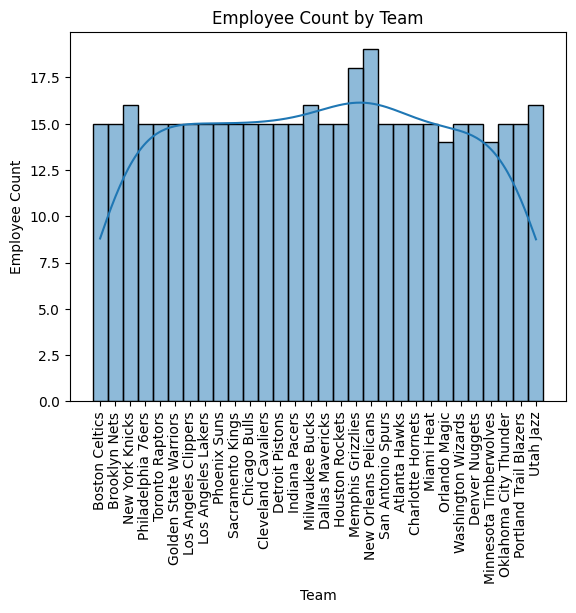

In [43]:
sns.histplot(data=df, x="Team", kde=True)
plt.xlabel('Team')
plt.ylabel('Employee Count')
plt.title('Employee Count by Team')
plt.xticks(rotation=90)
plt.show()

Insight: Employee count is high for New Orleans Pelicans. Other teams have almost similar employee counts

Analysis Question 2

In [20]:
position_count = df["Position"].value_counts()

position_count

,count
Position,
SG,102
PF,100
PG,92
SF,85
C,79


Graphical Question 2

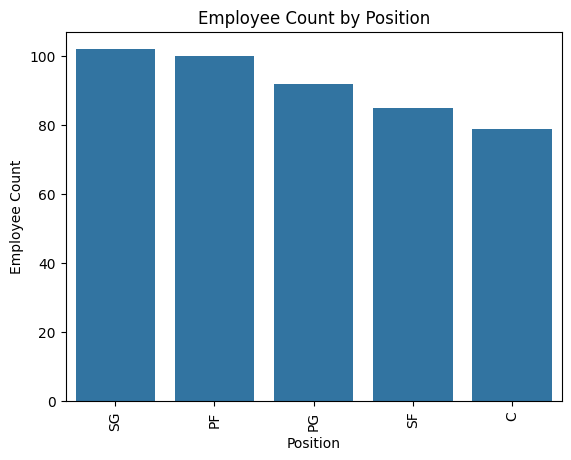

In [45]:
sns.barplot(x=position_count.index, y=position_count.values)
plt.xlabel('Position')
plt.ylabel('Employee Count')
plt.title('Employee Count by Position')
plt.xticks(rotation=90)
plt.show()



Insights: Employee count is high for SG position and low for C position

Analysis Question 3

In [32]:
age_group = df["Age"].value_counts().sort_index()

print(age_group.idxmax())

24


Graphical Question 3

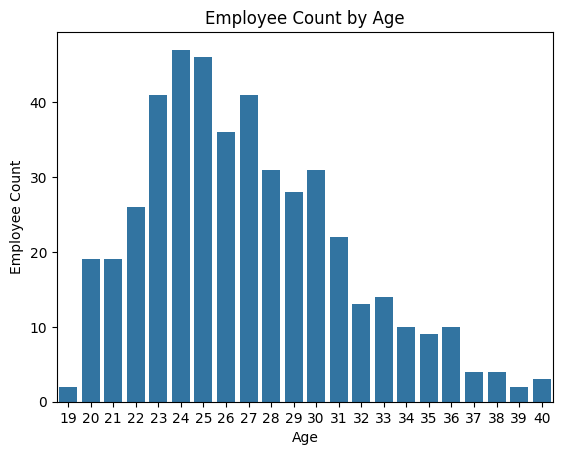

In [47]:
sns.countplot(data=df, x="Age")
plt.xlabel('Age')
plt.ylabel('Employee Count')
plt.title('Employee Count by Age')
plt.show()

Insight: More employees are in an age group of 23-27

Analysis Question 4

In [35]:
team_salary = df.groupby("Team")["Salary"].sum()
team_salary.sort_values(ascending=False)
print(team_salary.idxmax())

position_salary = df.groupby("Position")["Salary"].sum()
position_salary.sort_values(ascending=False)
print(position_salary.idxmax())

Cleveland Cavaliers
C


Graphical Question 4

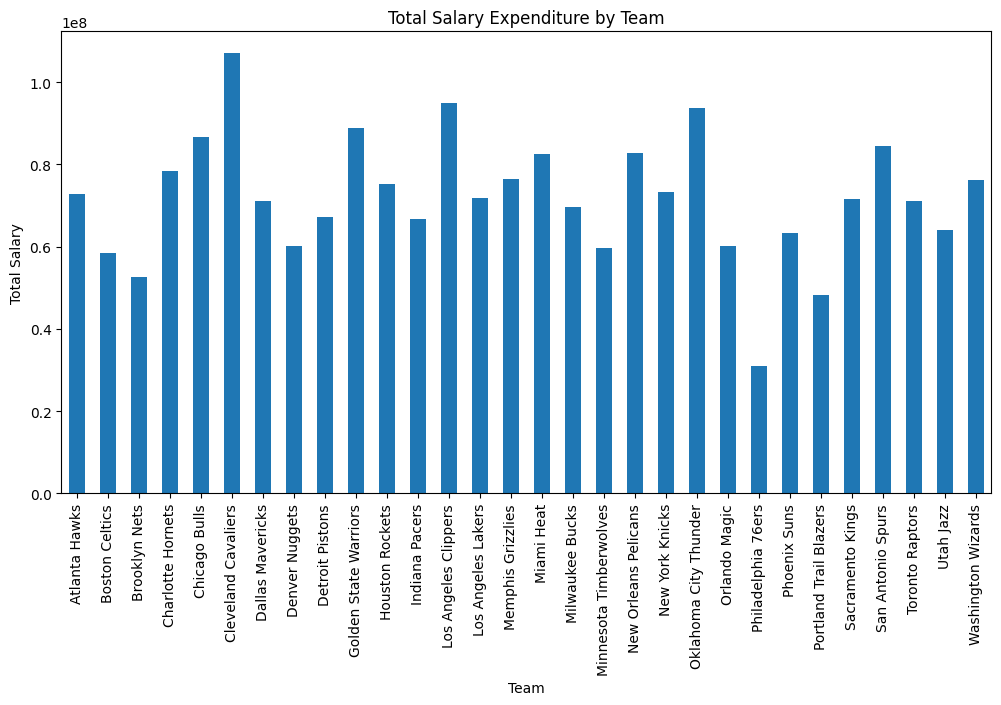

In [48]:
plt.figure(figsize=(12, 6))

team_salary.plot(kind="bar")

plt.title("Total Salary Expenditure by Team")
plt.xlabel("Team")
plt.ylabel("Total Salary")

plt.xticks(rotation=90)

plt.show()

Insight: Salary is very low for Orlando Magic. Salary expenditure varies across teams. Some teams have significantly higher total salary expenditure than others

Analysis Question 5

In [49]:
correlation = df["Age"].corr(df["Salary"])

print("Correlation between Age and Salary:", correlation)



Correlation between Age and Salary: 0.21400941226570971


Graphical Question 5

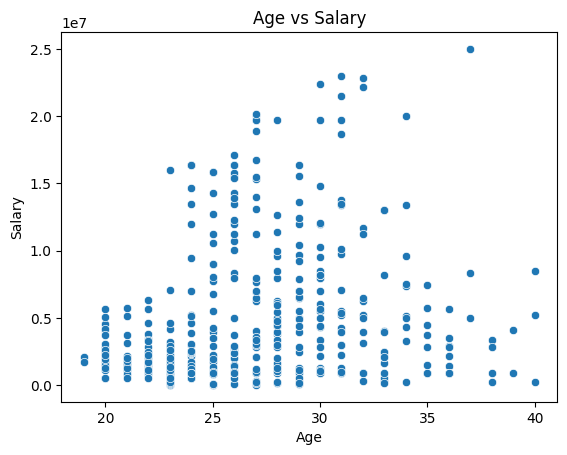

In [50]:
sns.scatterplot(data=df, x="Age", y="Salary")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")
plt.show()

Insight:Salary is high for age group between 25 to 35.Age below 20 and age above 35 has low salaries